In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Make sure you install geopy if Colab doesn't have it natively
!pip install geopy

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/911_Calls_For_Service_2026.csv")

In [ ]:
data.head()

,callKey,callDateTime,priority,district,description,callNumber,incidentLocation,location,Neighborhood,PoliceDistrict,...,CouncilDistrict,SheriffDistricts,Community_Statistical_Areas,Census_Tracts,VRIZones,ZIPCode,NeedsSync,IsDeleted,HashedRecord,ESRI_OID
0,11FE050A69568328,2026/01/01 09:21:00+00,Non-Emergency,TRU,FOLLOW UP,P260011899,200 N HILTON ST,200 N HILTON ST BALTIMORE MD,Saint Josephs,Southwestern,...,8.0,D10,Allendale/Irvington/S. Hilton,Census Tract 2007.01,NaN,21229.0,1,0,NaN,1
1,11FE050A69568F97,2026/01/01 10:14:00+00,Non-Emergency,WD,SICK CASE,P260012064,2200 MT ROYAL TE,2200 MT ROYAL TE BALTIMORE MD,Reservoir Hill,Central,...,7.0,D2,Penn North/Reservoir Hill,Census Tract 1301,NaN,21217.0,1,0,NaN,2
2,11FE050A6956B49B,2026/01/01 12:52:00+00,Non-Emergency,SE,PRKG COMPLAINT,P260012780,500 UMBRA ST,500 UMBRA ST BALTIMORE MD,Greektown,Southeastern,...,1.0,D6,Orangeville/East Highlandtown,Census Tract 2605.01,NaN,21224.0,1,0,NaN,3
3,11FE050A6956C548,2026/01/01 14:03:00+00,Medium,ED,MISSING PERSON,P260013020,500 E 23RD ST,500 E 23RD ST BALTIMORE MD,East Baltimore Midway,Eastern,...,12.0,D5,Midway/Coldstream,Census Tract 908,NaN,21218.0,1,0,NaN,4
4,12FE050A69566E20,2026/01/01 07:51:00+00,Non-Emergency,WD,NOISE COMPLAINT,P260011501,2100 BRYANT AV,2100 BRYANT AV BALTIMORE MD,Mondawmin,Western,...,7.0,D9,Greater Mondawmin,Census Tract 1504,NaN,21217.0,1,0,NaN,5


In [ ]:
df = data[['callDateTime', 'priority', 'district', 'location', 'Neighborhood', 'ZIPCode']]

In [ ]:
data.head()

,callKey,callDateTime,priority,district,description,callNumber,incidentLocation,location,Neighborhood,PoliceDistrict,...,CouncilDistrict,SheriffDistricts,Community_Statistical_Areas,Census_Tracts,VRIZones,ZIPCode,NeedsSync,IsDeleted,HashedRecord,ESRI_OID
0,11FE050A69568328,2026/01/01 09:21:00+00,Non-Emergency,TRU,FOLLOW UP,P260011899,200 N HILTON ST,200 N HILTON ST BALTIMORE MD,Saint Josephs,Southwestern,...,8.0,D10,Allendale/Irvington/S. Hilton,Census Tract 2007.01,NaN,21229.0,1,0,NaN,1
1,11FE050A69568F97,2026/01/01 10:14:00+00,Non-Emergency,WD,SICK CASE,P260012064,2200 MT ROYAL TE,2200 MT ROYAL TE BALTIMORE MD,Reservoir Hill,Central,...,7.0,D2,Penn North/Reservoir Hill,Census Tract 1301,NaN,21217.0,1,0,NaN,2
2,11FE050A6956B49B,2026/01/01 12:52:00+00,Non-Emergency,SE,PRKG COMPLAINT,P260012780,500 UMBRA ST,500 UMBRA ST BALTIMORE MD,Greektown,Southeastern,...,1.0,D6,Orangeville/East Highlandtown,Census Tract 2605.01,NaN,21224.0,1,0,NaN,3
3,11FE050A6956C548,2026/01/01 14:03:00+00,Medium,ED,MISSING PERSON,P260013020,500 E 23RD ST,500 E 23RD ST BALTIMORE MD,East Baltimore Midway,Eastern,...,12.0,D5,Midway/Coldstream,Census Tract 908,NaN,21218.0,1,0,NaN,4
4,12FE050A69566E20,2026/01/01 07:51:00+00,Non-Emergency,WD,NOISE COMPLAINT,P260011501,2100 BRYANT AV,2100 BRYANT AV BALTIMORE MD,Mondawmin,Western,...,7.0,D9,Greater Mondawmin,Census Tract 1504,NaN,21217.0,1,0,NaN,5


In [ ]:
df = df[df['priority'] != 'Non-Emergency']

In [ ]:
df.head()

,callDateTime,priority,district,location,Neighborhood,ZIPCode
3,2026/01/01 14:03:00+00,Medium,ED,500 E 23RD ST BALTIMORE MD,East Baltimore Midway,21218.0
5,2026/01/01 08:13:00+00,Medium,SW,0 S CARROLLTON AV BALTIMORE MD,Hollins Market,21223.0
6,2026/01/01 08:26:00+00,Low,NE,1300 PENTRIDGE RD BALTIMORE MD,New Northwood,21239.0
7,2026/01/01 09:39:00+00,Medium,ED,0 W 20TH ST BALTIMORE MD,Charles North,21218.0
8,2026/01/01 10:40:00+00,Low,SD,1200 CLARKSON ST BALTIMORE MD,Sharp-Leadenhall,21230.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96799 entries, 3 to 432762
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   callDateTime  96799 non-null  object 
 1   priority      96798 non-null  object 
 2   district      96799 non-null  object 
 3   location      96799 non-null  object 
 4   Neighborhood  96677 non-null  object 
 5   ZIPCode       96653 non-null  float64
dtypes: float64(1), object(5)
memory usage: 7.2+ MB


In [ ]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# 1. Clean up the address column (Assuming your column is named 'location')
# This turns '1600 BLK E FAYETTE ST' into '1600 E FAYETTE ST, Baltimore, MD'
df['clean_address'] = df['location'].str.replace(' BLK', '', regex=False)

# 2. Extract ONLY the unique addresses
unique_addresses = pd.DataFrame({'clean_address': df['clean_address'].dropna().unique()})

# Let's test it on just the first 10 unique addresses so you don't wait forever
test_batch = unique_addresses.head(10).copy()

In [ ]:
import pandas as pd
import os
import time
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# 1. Setup the Geocoder with a slightly safer delay
geolocator = Nominatim(user_agent="baltimore_ems_model_v1")
geocode_with_delay = RateLimiter(geolocator.geocode, min_delay_seconds=1.5)

# 2. Define our save file
save_file = '/content/drive/MyDrive/baltimore_saved_coordinates.csv'

# 3. Load existing progress if the file already exists (so we don't start over!)
if os.path.exists(save_file):
    saved_data = pd.read_csv(save_file)
    completed_addresses = set(saved_data['clean_address'])
    print(f"Loaded {len(completed_addresses)} already completed addresses.")
else:
    # If starting fresh, create an empty dataframe and save it
    saved_data = pd.DataFrame(columns=['clean_address', 'lat', 'long'])
    saved_data.to_csv(save_file, index=False)
    completed_addresses = set()

# 4. Filter out the addresses we've already done
addresses_to_do = unique_addresses[~unique_addresses['clean_address'].isin(completed_addresses)]['clean_address'].tolist()
print(f"Addresses remaining to geocode: {len(addresses_to_do)}")

# 5. Process in small batches and save immediately
batch_size = 50
for i in range(0, len(addresses_to_do), batch_size):
    batch = addresses_to_do[i:i+batch_size]
    print(f"Processing batch {i} to {i+len(batch)}...")

    batch_results = []
    for address in batch:
        try:
            loc = geocode_with_delay(address)
            lat = loc.latitude if loc else None
            long = loc.longitude if loc else None
            batch_results.append({'clean_address': address, 'lat': lat, 'long': long})
        except Exception as e:
            print(f"Error on {address}: {e}")
            batch_results.append({'clean_address': address, 'lat': None, 'long': None})
            time.sleep(5) # Back off if there's a hard error

    # Append the batch to the CSV immediately
    pd.DataFrame(batch_results).to_csv(save_file, mode='a', header=False, index=False)

print("Finished geocoding! All safe and saved.")

Loaded 15811 already completed addresses.
Addresses remaining to geocode: 0
Finished geocoding! All safe and saved.


In [ ]:

# 1. Loading lats and longs
coords_df = pd.read_csv('/content/drive/MyDrive/baltimore_saved_coordinates.csv')

# 2. Drop empty rows
clean_coords = coords_df.dropna(subset=['lat', 'long'])

# 3. Merge saved coordinates with main dataset
final_df = df.merge(clean_coords, on='clean_address', how='inner')

# 4. Check our final numbers
print(f"Original unique addresses: {len(coords_df)}")
print(f"Successfully geocoded unique addresses: {len(clean_coords)}")
print(f"Total historical 911 calls ready for clustering: {len(final_df)}")

# Preview the final, perfect data
print(final_df[['callDateTime', 'priority', 'clean_address', 'lat', 'long']].head())

Original unique addresses: 15811
Successfully geocoded unique addresses: 10571
Total historical 911 calls ready for clustering: 81059
             callDateTime priority                   clean_address        lat  \
0  2026/01/01 14:03:00+00   Medium      500 E 23RD ST BALTIMORE MD  39.315601   
1  2026/01/01 08:13:00+00   Medium  0 S CARROLLTON AV BALTIMORE MD  39.287133   
2  2026/01/01 08:26:00+00      Low  1300 PENTRIDGE RD BALTIMORE MD  39.347787   
3  2026/01/01 09:39:00+00   Medium        0 W 20TH ST BALTIMORE MD  39.312195   
4  2026/01/01 10:40:00+00      Low   1200 CLARKSON ST BALTIMORE MD  39.271499   

        long  
0 -76.609342  
1 -76.636660  
2 -76.595196  
3 -76.617277  
4 -76.616039  


In [ ]:
# Filter for coordinates only within Baltimore city limits
final_df = final_df[
    (final_df['lat'].between(39.19, 39.38)) &
    (final_df['long'].between(-76.72, -76.52))
]

print(f"Rows remaining after cleaning outliers: {len(final_df)}")

Rows remaining after cleaning outliers: 80959


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80959 entries, 0 to 81058
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   callDateTime   80959 non-null  object 
 1   priority       80958 non-null  object 
 2   district       80959 non-null  object 
 3   location       80959 non-null  object 
 4   Neighborhood   80905 non-null  object 
 5   ZIPCode        80892 non-null  float64
 6   clean_address  80959 non-null  object 
 7   lat            80959 non-null  float64
 8   long           80959 non-null  float64
dtypes: float64(3), object(6)
memory usage: 6.2+ MB


In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# 1. Isolate the exact coordinates for the algorithm
# We drop any lingering NaNs just to be absolutely safe before feeding it to sklearn
X = final_df[['lat', 'long']].dropna()

# 2. Initialize and run K-Means
print("Running K-Means to create 100 Demand Zones. This should take less than a minute...")
kmeans = KMeans(n_clusters=100, random_state=42, n_init=10)
final_df['demand_zone_id'] = kmeans.fit_predict(X)

# 3. Calculate the weights (w_i) - how many total calls happened in each zone
zone_weights = final_df['demand_zone_id'].value_counts().reset_index()
zone_weights.columns = ['demand_zone_id', 'call_volume_wi']

# 4. Extract the exact center coordinates of each of the 100 zones
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['center_lat', 'center_long'])
centers['demand_zone_id'] = centers.index

# 5. Merge the centers and weights into your final, clean Demand Zones table
demand_zones_df = centers.merge(zone_weights, on='demand_zone_id')

print(f"\nSuccessfully created {len(demand_zones_df)} Demand Zones!")
print(demand_zones_df.head())

Running K-Means to create 100 Demand Zones. This should take less than a minute...

Successfully created 100 Demand Zones!
   center_lat  center_long  demand_zone_id  call_volume_wi
0   39.305182   -76.579339               0             872
1   39.307785   -76.653566               1             860
2   39.232025   -76.599003               2             904
3   39.348942   -76.692351               3             818
4   39.302078   -76.626694               4            2026


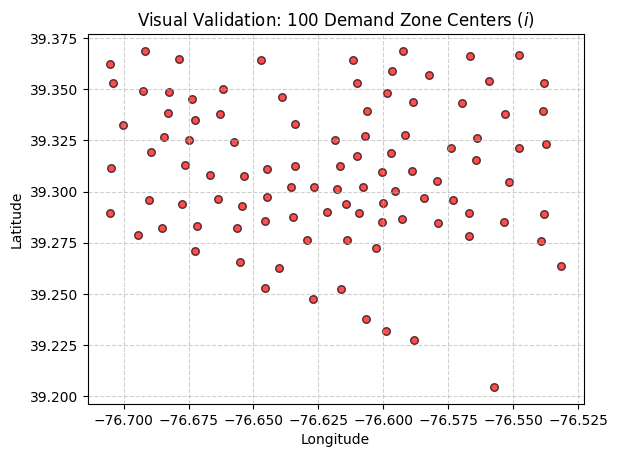

In [ ]:
import matplotlib.pyplot as plt

# Plot the 100 centers
plt.scatter(demand_zones_df['center_long'], demand_zones_df['center_lat'], s=30, c='red', edgecolors='black', alpha=0.7)

# Add labels and title
plt.title("Visual Validation: 100 Demand Zone Centers ($i$)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import folium
from folium.plugins import Fullscreen

# Center the map on Baltimore
baltimore_center = [39.2904, -76.6122]
m = folium.Map(location=baltimore_center, zoom_start=12, tiles='CartoDB Positron')

# Add the 100 Demand Zones
for _, row in demand_zones_df.iterrows():
    # Dynamic radius for interaction (min size of 3, max of 15)
    rad = (row['call_volume_wi'] / demand_zones_df['call_volume_wi'].max()) * 15 + 3

    folium.CircleMarker(
        location=[row['center_lat'], row['center_long']],
        radius=rad,
        popup=folium.Popup(f"""
            <b>Demand Zone ID:</b> {int(row['demand_zone_id'])}<br>
            <b>Annual Call Volume:</b> {int(row['call_volume_wi'])} calls<br>
            <b>Coordinates:</b> {round(row['center_lat'],4)}, {round(row['center_long'],4)}
        """, max_width=200),
        color='darkred',
        fill=True,
        fill_color='red',
        fill_opacity=0.6
    ).add_to(m)

Fullscreen().add_to(m) # Adds a "Full Screen" button for your presentation
m.save('baltimore_interactive_demand.html')
m

In [ ]:
# You'll need to install this in Colab first
!pip install contextily

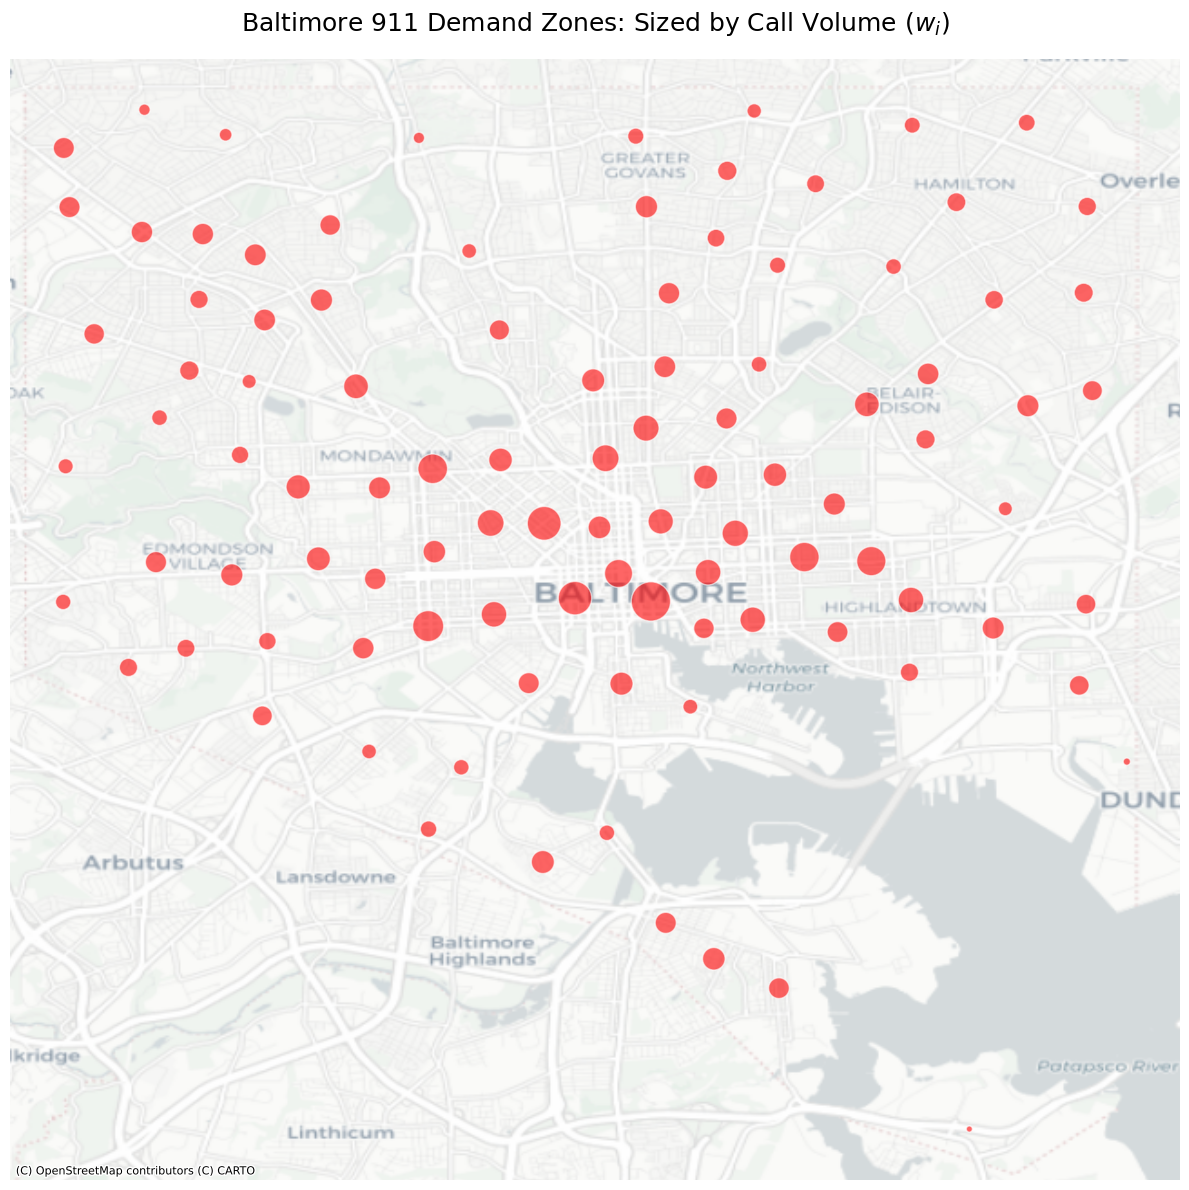

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

# Create the plot
fig, ax = plt.subplots(figsize=(12, 12))

# We use (call_volume / total_calls * 5000) to make the sizing dramatic but readable
sizes = (demand_zones_df['call_volume_wi'] / demand_zones_df['call_volume_wi'].max()) * 800

ax.scatter(demand_zones_df['center_long'], demand_zones_df['center_lat'],
           s=sizes, c='red', alpha=0.6, edgecolors='white', linewidth=1, zorder=2)

# Add the high-res Baltimore background
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron)

ax.set_title("Baltimore 911 Demand Zones: Sized by Call Volume ($w_i$)", fontsize=18, pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('baltimore_demand_static.png', dpi=300) # Save high-res for your slides
plt.show()

In [ ]:
import pandas as pd

# 1. Load the official Maryland dataset from Google Drive
raw_stations = pd.read_csv('/content/drive/MyDrive/County_Fire_Stations.csv')

# 2. Filter for Baltimore City Career stations
stations_df = raw_stations[
    (raw_stations['City'] == 'Baltimore') &
    (raw_stations['Type'] == 'Career')
].copy()

# 3. Clean 'the_geom' column to extract Latitude and Longitude
# It looks like: POINT (-76.608203 39.272714)
stations_df['Longitude'] = stations_df['the_geom'].str.extract(r'\((-\d+\.\d+)').astype(float)
stations_df['Latitude'] = stations_df['the_geom'].str.extract(r'\s(\d+\.\d+)\)').astype(float)

# 4. Final Cleanup
stations_df = stations_df[['Station Name', 'Address', 'Latitude', 'Longitude']].reset_index(drop=True)
stations_df['site_id'] = stations_df.index

print(f"Successfully cleaned {len(stations_df)} official Baltimore Fire Stations!")
display(stations_df.head())

Successfully cleaned 58 official Baltimore Fire Stations!


,Station Name,Address,Latitude,Longitude,site_id
0,Baltimore City Fire Station 35,399 E Fort Ave,39.272714,-76.608203,0
1,Baltimore City Fire Academy,6720 Pulaski Hwy,39.307456,-76.534154,1
2,Baltimore City Fire Headquarters Station 24,414 N Calvert St,39.294405,-76.612840,2
3,Baltimore City Fire Station 18,1908 Hollins St,39.287286,-76.647520,3
4,Baltimore City Fire Station 15,3130 W North Ave,39.309202,-76.670576,4


In [ ]:
import numpy as np
from sklearn.metrics.pairwise import haversine_distances

# 1. Define our research-backed constants
CIRCUITY_FACTOR = 1.33  # Baltimore-specific adjustment (Giacomin & Levinson, 2015)
SPEED_MILES_MIN = 0.5   # 30 mph as defined in your report
DISPATCH_PENALTY = 1.0  # 1-minute turnout time
MAX_TIME_LIMIT = 29.0   # Survival goes to 0 after this point

def calculate_optimized_matrix(calls_df, stations_df):
    # Convert lat/long to radians for Haversine
    calls_coords = np.radians(calls_df[['lat', 'long']])
    station_coords = np.radians(stations_df[['Latitude', 'Longitude']])

    num_zones = 100
    num_stations = len(stations_df)

    # Initialize matrices
    t_ij = np.zeros((num_zones, num_stations))
    p_ij = np.zeros((num_zones, num_stations))

    print("Starting matrix calculation for 80,959 calls across 58 stations...")

    for i in range(num_zones):
        # Extract calls belonging to this specific cluster/zone
        zone_calls = calls_coords[calls_df['demand_zone_id'] == i]

        if len(zone_calls) > 0:
            # A. Calculate Haversine distance (Earth Radius = 3958.8 miles)
            dist_matrix = haversine_distances(zone_calls, station_coords) * 3958.8

            # B. Apply Circuity Factor to get "Street Miles"
            street_dist = dist_matrix * CIRCUITY_FACTOR

            # C. Convert to Travel Time: (Distance / Speed) + Dispatch
            # This creates a (calls_in_zone x 58) time matrix
            time_matrix = (street_dist / SPEED_MILES_MIN) + DISPATCH_PENALTY

            # D. Take the MEAN for the zone (Professor's Feedback requirement)
            mean_times = time_matrix.mean(axis=0)
            t_ij[i, :] = mean_times

            # E. Calculate Survival Probability (Larsen et al. 1993)
            # Probability P = 0.67 - 0.023 * time
            survival_probs = 0.67 - (0.023 * mean_times)

            # Clip probabilities between 0 and 0.67
            p_ij[i, :] = np.clip(survival_probs, 0, 0.67)

            # F. Enforce the 29-minute rule (Set P to 0 if time > 29)
            p_ij[i, t_ij[i, :] > MAX_TIME_LIMIT] = 0

    return t_ij, p_ij

# Run the final math
t_ij_matrix, p_ij_matrix = calculate_optimized_matrix(final_df, stations_df)

print("\n--- Math Locked In ---")
print(f"Travel Time Matrix (t_ij) Shape: {t_ij_matrix.shape}")
print(f"Survival Probability Matrix (p_ij) Shape: {p_ij_matrix.shape}")
print(f"Average Survival Prob across Baltimore: {p_ij_matrix.mean():.4f}")

Starting matrix calculation for 80,959 calls across 58 stations...

--- Math Locked In ---
Travel Time Matrix (t_ij) Shape: (100, 58)
Survival Probability Matrix (p_ij) Shape: (100, 58)
Average Survival Prob across Baltimore: 0.3383


In [ ]:
!pip install pulp

In [ ]:
import pulp

def solve_ambulance_optimization(P_count, w_i, p_ij, t_ij):
    # 1. Create the Problem
    prob = pulp.LpProblem("Maximize_Baltimore_Survival", pulp.LpMaximize)

    # 2. Variables
    # x_j: Is station j open? (Binary)
    # y_ij: Fraction of zone i assigned to station j (Continuous 0 to 1)
    x = pulp.LpVariable.dicts("station_open", range(58), cat='Binary')
    y = pulp.LpVariable.dicts("assignment", (range(100), range(58)), 0, 1, cat='Continuous')

    # 3. Objective Function: Maximize total expected survivors
    # Sum of (Call Volume * Survival Probability * Assignment Fraction)
    prob += pulp.lpSum(w_i[i] * p_ij[i][j] * y[i][j] for i in range(100) for j in range(58))

    # 4. Constraints

    # C1: Total ambulances allowed
    prob += pulp.lpSum(x[j] for j in range(58)) == P_count

    # C2: Every zone must have 100% of its demand assigned
    for i in range(100):
        prob += pulp.lpSum(y[i][j] for j in range(58)) == 1

    # C3: You can only assign a zone to a station if that station is OPEN
    for i in range(100):
        for j in range(58):
            prob += y[i][j] <= x[j]

    # C4: Professor's Capacity Constraint (Realistic Busy Time)
    # Total minutes used per year per ambulance <= 210,240 (0.40 UHU)
    # We assume each call takes (Travel Time + 45 mins on-scene/hospital)
    TASK_TIME = 45
    MAX_MINUTES_YEAR = 210240

    for j in range(58):
        prob += pulp.lpSum(w_i[i] * y[i][j] * (t_ij[i][j] + TASK_TIME) for i in range(100)) <= MAX_MINUTES_YEAR

    # 5. Solve
    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    return prob, x, y

w_i = demand_zones_df.groupby('demand_zone_id')['call_volume_wi'].first().values
status, x_res, y_res = solve_ambulance_optimization(35, w_i, p_ij_matrix, t_ij_matrix)

print(f"Optimization Status: {pulp.LpStatus[status.status]}")

Optimization Status: Optimal


In [ ]:
# Quick feasibility check
total_workload_mins = np.sum(w_i * (t_ij_matrix.mean(axis=1) + 45))
min_ambulances_needed = total_workload_mins / 210240

print(f"Total workload requires at least {min_ambulances_needed:.2f} ambulances.")

Total workload requires at least 22.69 ambulances.


In [ ]:
status_25, x_res_25, y_res_25 = solve_ambulance_optimization(25, w_i, p_ij_matrix, t_ij_matrix)

selected_indices_25 = [j for j in range(58) if x_res_25[j].varValue > 0.5]

optimal_stations_25 = stations_df.iloc[selected_indices_25].copy()

print(f"Selected {len(optimal_stations_25)} stations for P=25:")
display(optimal_stations_25[['Station Name', 'Address']])

Selected 25 stations for P=25:


,Station Name,Address
3,Baltimore City Fire Station 18,1908 Hollins St
4,Baltimore City Fire Station 15,3130 W North Ave
6,Baltimore City Fire Station 12,801 E 25Th St
7,Baltimore City Fire Station 39,5714 Eastern Ave
12,Baltimore City Fire Station 40,5821 Belair Road
14,Baltimore City Fire Station 38,430 Maude Ave
15,Baltimore City Fire Station 22,405 Mcmechen St
16,Baltimore City Fire Station 3,3906 Liberty Heights Ave
17,Baltimore City Fire Station 13,4315 Mannasota Ave
18,Baltimore City Engine 6,1100 Hillen St


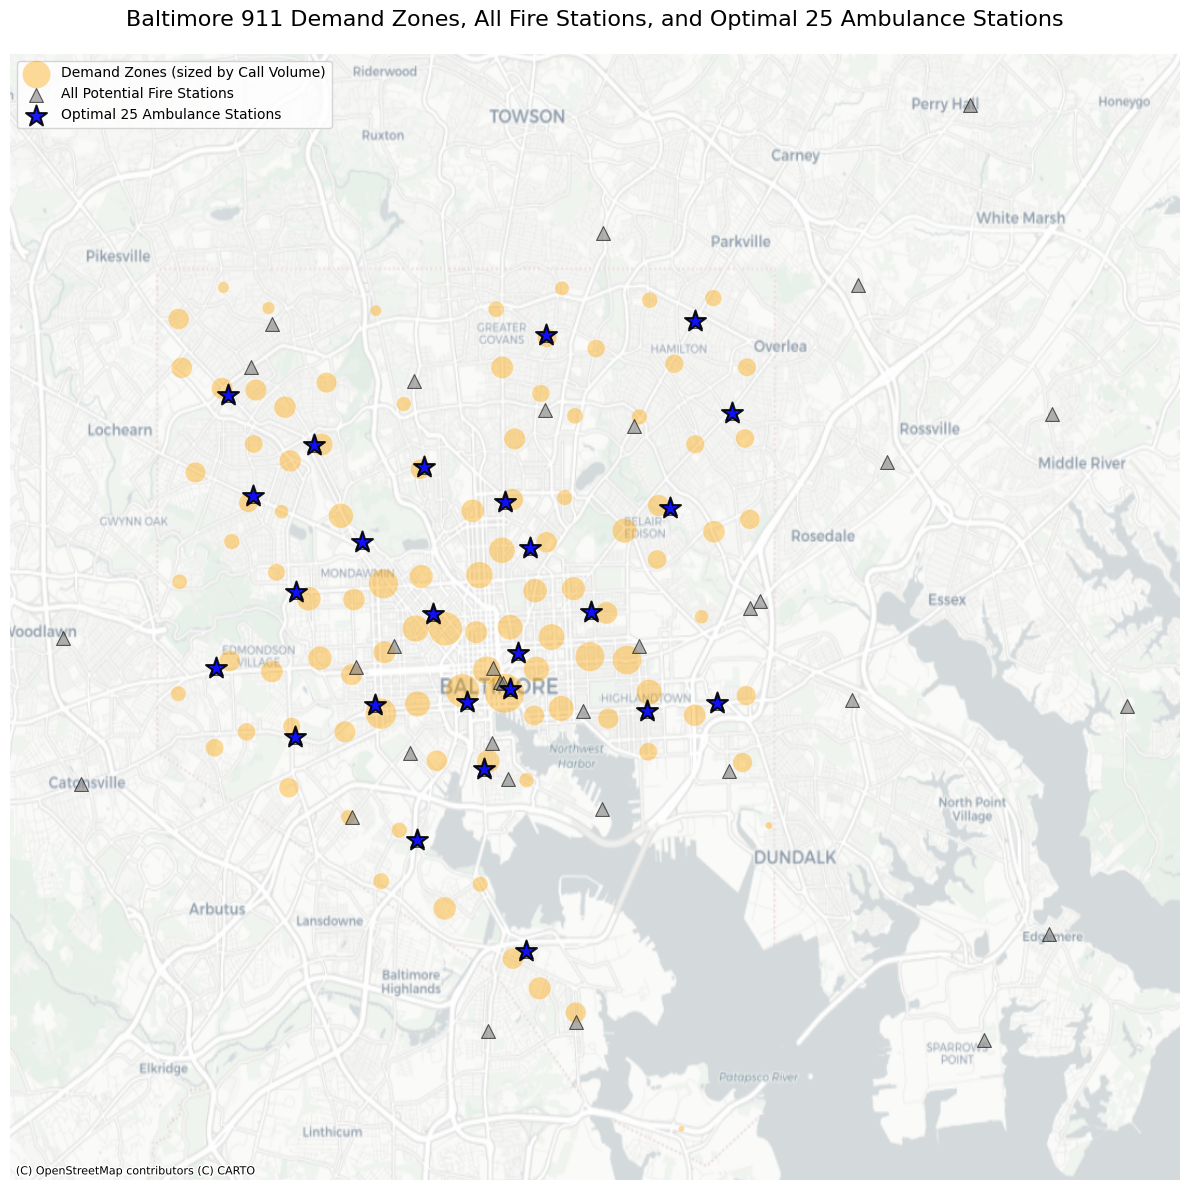

In [ ]:
import matplotlib.pyplot as plt
import contextily as ctx

fig, ax = plt.subplots(figsize=(12, 12))

sizes_demand_zones = (demand_zones_df['call_volume_wi'] / demand_zones_df['call_volume_wi'].max()) * 800

ax.scatter(demand_zones_df['center_long'], demand_zones_df['center_lat'],
           s=sizes_demand_zones, c='orange', alpha=0.4, edgecolors='white', linewidth=0.5, zorder=1,
           label='Demand Zones (sized by Call Volume)')

ax.scatter(stations_df['Longitude'], stations_df['Latitude'],
           s=100, c='grey', marker='^', alpha=0.6, edgecolors='black', linewidth=0.8, zorder=2,
           label='All Potential Fire Stations')

ax.scatter(optimal_stations_25['Longitude'], optimal_stations_25['Latitude'],
           s=250, c='blue', marker='*', alpha=0.9, edgecolors='black', linewidth=1.5, zorder=3,
           label='Optimal 25 Ambulance Stations')

ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron)

ax.set_title("Baltimore 911 Demand Zones, All Fire Stations, and Optimal 25 Ambulance Stations", fontsize=16, pad=20)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_axis_off()

plt.legend(loc='upper left', fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig('baltimore_demand_all_and_optimal_25_stations_static.png', dpi=300)
plt.show()

In [ ]:
P_counts_to_test = [23, 24, 25, 35, 36, 45, 46, 47, 50, 52, 55, 58]
w_i = demand_zones_df.groupby('demand_zone_id')['call_volume_wi'].first().values

print("\n--- Evaluating Different Ambulance Counts ---")
for p_val in P_counts_to_test:
    print(f"\nRunning optimization for P = {p_val} ambulances...")
    status, x_res, y_res = solve_ambulance_optimization(p_val, w_i, p_ij_matrix, t_ij_matrix)

    if pulp.LpStatus[status.status] == 'Optimal':
        total_expected_survivors = pulp.value(status.objective)
        average_survival_rate = total_expected_survivors / w_i.sum()

        print(f"  Optimization Status: {pulp.LpStatus[status.status]}")
        print(f"  Final City-Wide Survival Rate: {average_survival_rate:.2%}")
        print(f"  Total Expected Survivors per Year: {total_expected_survivors:.0f}")
    else:
        print(f"  Optimization failed for P = {p_val}: {pulp.LpStatus[status.status]}")


--- Evaluating Different Ambulance Counts ---

Running optimization for P = 23 ambulances...
  Optimization Status: Optimal
  Final City-Wide Survival Rate: 60.67%
  Total Expected Survivors per Year: 49116

Running optimization for P = 24 ambulances...
  Optimization Status: Optimal
  Final City-Wide Survival Rate: 60.76%
  Total Expected Survivors per Year: 49192

Running optimization for P = 25 ambulances...
  Optimization Status: Optimal
  Final City-Wide Survival Rate: 60.83%
  Total Expected Survivors per Year: 49251

Running optimization for P = 35 ambulances...
  Optimization Status: Optimal
  Final City-Wide Survival Rate: 61.30%
  Total Expected Survivors per Year: 49630

Running optimization for P = 36 ambulances...
  Optimization Status: Optimal
  Final City-Wide Survival Rate: 61.32%
  Total Expected Survivors per Year: 49647

Running optimization for P = 45 ambulances...
  Optimization Status: Optimal
  Final City-Wide Survival Rate: 61.39%
  Total Expected Survivors per

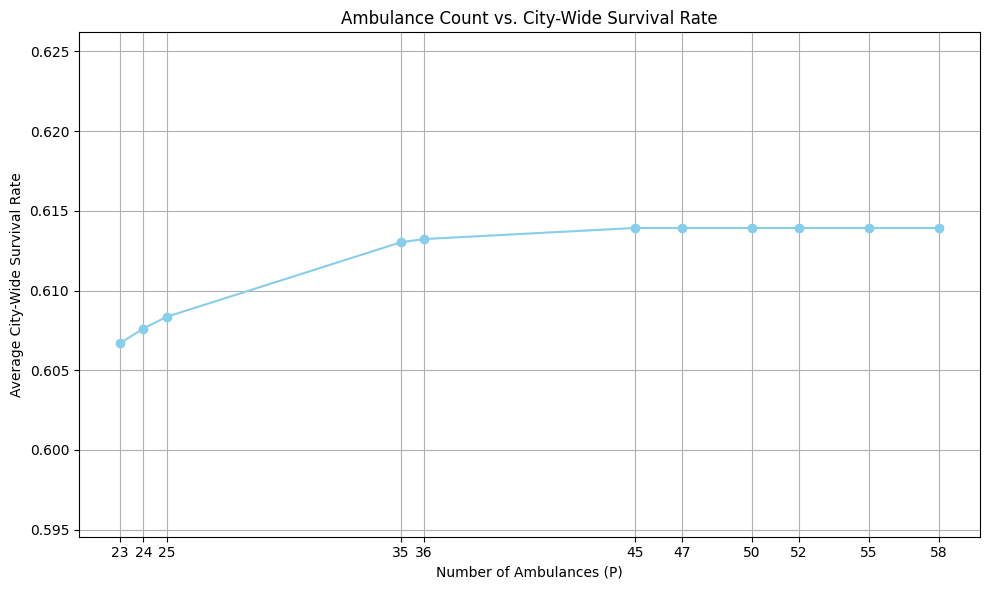


--- Marginal Increase in Survivors ---
Adding 1 ambulances (from 23 to 24): Marginal increase of 75.29 survivors per ambulance
Adding 1 ambulances (from 24 to 25): Marginal increase of 59.69 survivors per ambulance
Adding 10 ambulances (from 25 to 35): Marginal increase of 37.85 survivors per ambulance
Adding 1 ambulances (from 35 to 36): Marginal increase of 16.61 survivors per ambulance
Adding 9 ambulances (from 36 to 45): Marginal increase of 6.24 survivors per ambulance
Adding 2 ambulances (from 45 to 47): Marginal increase of 0.00 survivors per ambulance
Adding 3 ambulances (from 47 to 50): Marginal increase of 0.00 survivors per ambulance
Adding 2 ambulances (from 50 to 52): Marginal increase of 0.00 survivors per ambulance
Adding 3 ambulances (from 52 to 55): Marginal increase of 0.00 survivors per ambulance
Adding 3 ambulances (from 55 to 58): Marginal increase of 0.00 survivors per ambulance


In [ ]:
import matplotlib.pyplot as plt

P_counts_to_test = [23, 24, 25, 35, 36, 45, 47, 50, 52, 55, 58]

w_i = demand_zones_df.groupby('demand_zone_id')['call_volume_wi'].first().values

survival_rates = []
total_survivors_list = []

for p_val in P_counts_to_test:
    status, x_res, y_res = solve_ambulance_optimization(p_val, w_i, p_ij_matrix, t_ij_matrix)
    if pulp.LpStatus[status.status] == 'Optimal':
        total_expected_survivors = pulp.value(status.objective)
        average_survival_rate = total_expected_survivors / w_i.sum()
        survival_rates.append(average_survival_rate)
        total_survivors_list.append(total_expected_survivors)
    else:
        survival_rates.append(None) # Handle cases where optimization might fail
        total_survivors_list.append(None)

# Filter out None values if any optimization failed
valid_p_counts = [P_counts_to_test[i] for i, rate in enumerate(survival_rates) if rate is not None]
valid_survival_rates = [rate for rate in survival_rates if rate is not None]
valid_total_survivors = [ts for ts in total_survivors_list if ts is not None]

plt.figure(figsize=(10, 6))
plt.plot(valid_p_counts, valid_survival_rates, marker='o', linestyle='-', color='skyblue')
plt.title('Ambulance Count vs. City-Wide Survival Rate')
plt.xlabel('Number of Ambulances (P)')
plt.ylabel('Average City-Wide Survival Rate')
plt.grid(True)
plt.xticks(valid_p_counts) # Ensure x-ticks match tested P values
plt.ylim(min(valid_survival_rates) * 0.98, max(valid_survival_rates) * 1.02) # Adjust y-axis for better visibility
plt.tight_layout()
plt.show()

print("\n--- Marginal Increase in Survivors ---")
for i in range(1, len(valid_p_counts)):
    p_diff = valid_p_counts[i] - valid_p_counts[i-1]
    survivor_diff = valid_total_survivors[i] - valid_total_survivors[i-1]
    if p_diff > 0:
        marginal_increase = survivor_diff / p_diff
        print(f"Adding {p_diff} ambulances (from {valid_p_counts[i-1]} to {valid_p_counts[i]}): Marginal increase of {marginal_increase:.2f} survivors per ambulance")
    else:
        print(f"No increase in ambulances from {valid_p_counts[i-1]} to {valid_p_counts[i]}")